# How Has Netflix’s Content Strategy Evolved Over Time?

## Objective
The goal of this project is to analyse Netflix's catalogue of movies and TV shows to understand how its content strategy has changed over time.

## Key Questions
- How has the volume of Netflix content changed over time?
- Are movies or TV shows more common on the platform?
- Which countries contribute the most content?
- What genres are most common?
- What do these patterns suggest about Netflix's strategy?

## Importing libraries

In this section, I import the Python libraries needed for data manipulation and visualisation.  
- `pandas` will be used for cleaning and analysing the dataset  
- `matplotlib` and `seaborn` will be used to create charts

In [6]:
# Import core libraries for data analysis and visualisation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look cleaner
sns.set_style("whitegrid")

# Display all columns when needed
pd.set_option("display.max_columns", None)

## Loading the dataset

I now load the Netflix dataset and inspect its structure to understand:
- the number of rows and columns
- the variable names
- missing values
- the general quality of the data

In [7]:
# Load the CSV file into a pandas DataFrame
df = pd.read_csv("netflix_titles.csv")

# Display the first 5 rows to understand the structure
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Before starting the analysis, I want to check the size of the dataset, the data types, and the amount of missing data.

In [9]:
# Check the number of rows and columns
print("Shape of dataset:", df.shape)

# Check column names and data types
print("\nData types and non-null counts:")
print(df.info())

# Check missing values in each column
print("\nMissing values by column:")
print(df.isnull().sum().sort_values(ascending=False))

Shape of dataset: (8807, 12)

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

Missing values by column:
director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type       

To make the dataset usable for analysis, I will:
- remove duplicate rows if any exist
- convert dates into proper datetime format
- extract useful time information
- handle missing values where necessary
- standardise text fields

In [14]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates if they exist
df = df.drop_duplicates()

# Convert date_added to datetime format
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Extract year and month added to Netflix
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

# Clean whitespace in text columns that are important for grouping
text_columns = ["type", "country", "rating", "duration", "listed_in"]
for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

# Quick check after cleaning
df.head()

Duplicate rows: 0


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",nan,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,nan,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September


Because some titles have multiple countries and genres listed, I will keep the original columns for now and create simpler derived columns later when needed.

In [15]:
# Check missing values again after creating new columns
df.isnull().sum().sort_values(ascending=False)

director        2634
cast             825
date_added        10
year_added        10
month_added       10
show_id            0
type               0
title              0
country            0
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64

### Cleaning insight
The most important cleaning step is converting `date_added` into a datetime format, because this allows us to analyse how Netflix's catalogue changed over time.  
Missing values remain in some descriptive columns, but the dataset is now ready for the main analysis.

## Comparing movies and TV shows

A useful first step is to understand the composition of Netflix's catalogue.  
This tells us whether the platform is dominated by movies or TV shows.

Movie      6131
TV Show    2676
Name: type, dtype: int64


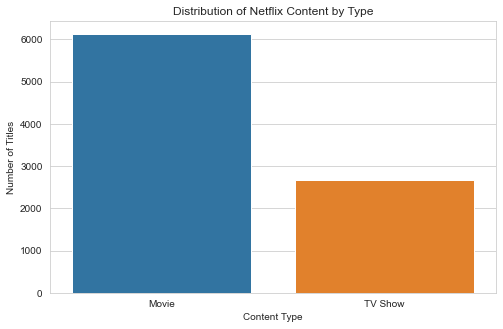

In [18]:
# Count the number of Movies and TV Shows
type_counts = df["type"].value_counts()

# Print counts
print(type_counts)

# Plot the distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="type")
plt.title("Distribution of Netflix Content by Type")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

### Insight
The catalogue is dominated by movies, with TV shows making up a smaller share of the total content.  
This suggests that Netflix has historically relied more heavily on films, although deeper time-based analysis is needed to see whether that changed over time.

## Analysing how content was added over time

To understand Netflix's expansion strategy, I will examine how many titles were added to the platform each year.
This is more informative than looking only at release year, because `date_added` tells us when titles entered the Netflix catalogue.

2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: year_added, dtype: int64


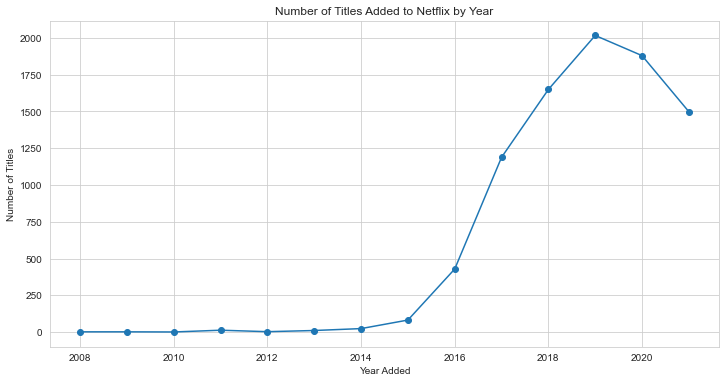

In [20]:
# Count how many titles were added in each year
content_by_year = df["year_added"].value_counts().sort_index()

# Print results
print(content_by_year)

# Plot titles added by year
plt.figure(figsize=(12, 6))
content_by_year.plot(kind="line", marker="o")
plt.title("Number of Titles Added to Netflix by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()

### Insight
The number of titles added to Netflix rises sharply in later years, showing a period of rapid catalogue expansion.  
This likely reflects Netflix's push to scale its content library aggressively as competition in streaming increased.

## Movies vs TV shows over time

The next step is to investigate whether Netflix's content growth was driven mainly by movies or whether TV shows became more important over time.

type         Movie  TV Show
year_added                 
2017.0       839.0    349.0
2018.0      1237.0    412.0
2019.0      1424.0    592.0
2020.0      1284.0    595.0
2021.0       993.0    505.0


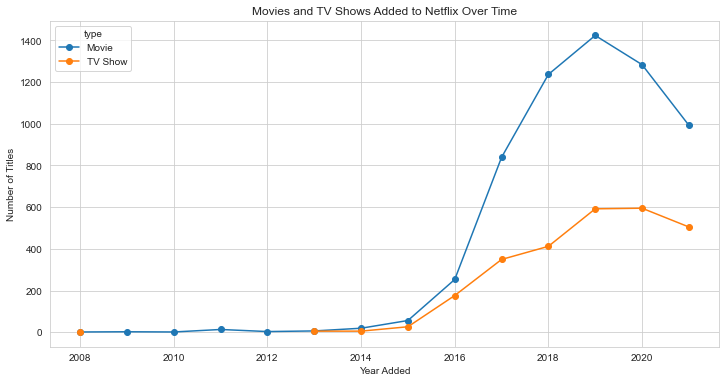

In [21]:
# Group by year added and content type
year_type_counts = df.groupby(["year_added", "type"]).size().unstack()

# Display grouped data
print(year_type_counts.tail())

# Plot the results
year_type_counts.plot(figsize=(12, 6), marker="o")
plt.title("Movies and TV Shows Added to Netflix Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()

### Insight
Movies remain the larger category overall, but TV shows may show strong growth in later years.  
If the TV show trend rises faster over time, this could indicate a strategic shift toward series-based content, which often drives stronger subscriber retention.

## Identifying the top countries

Netflix is a global platform, so it is useful to see which countries contribute the most content.  
Because many rows contain multiple countries, I will simplify the analysis by taking the first listed country for each title.

United States     3211
India             1008
Unknown            831
United Kingdom     628
Canada             271
Japan              259
France             212
South Korea        211
Spain              181
Mexico             134
Name: main_country, dtype: int64


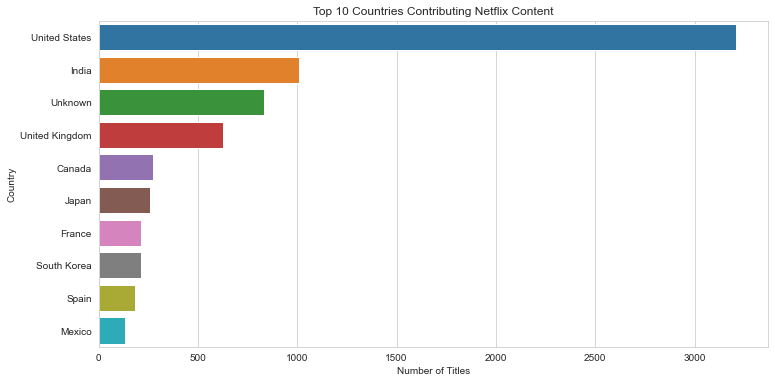

In [23]:
# Create a simplified country column using the first listed country
df["main_country"] = df["country"].apply(lambda x: x.split(",")[0].strip() if x != "nan" else "Unknown")

# Count titles by country
top_countries = df["main_country"].value_counts().head(10)

# Print results
print(top_countries)

# Plot top 10 countries
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries Contributing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

### Insight
A small number of countries contribute a large share of Netflix's catalogue.  
This shows that although Netflix is global, content production remains concentrated in a few major markets.

## Analysing the most common genres

The `listed_in` column contains multiple genres per title.  
To simplify the analysis, I will extract the first listed genre and identify which categories dominate the catalogue.

Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       774
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     388
Stand-Up Comedy              334
Horror Movies                275
Name: main_genre, dtype: int64


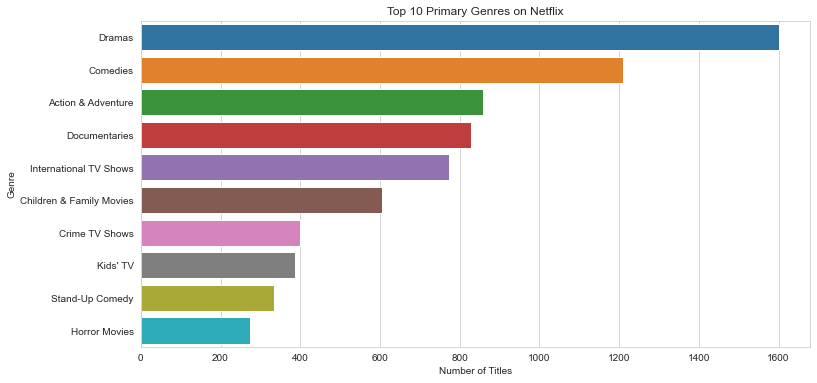

In [26]:
# Create a simplified genre column using the first listed genre
df["main_genre"] = df["listed_in"].apply(lambda x: x.split(",")[0].strip())

# Count most common genres
top_genres = df["main_genre"].value_counts().head(10)

# Print results
print(top_genres)

# Plot top genres
plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Primary Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

### Insight
Some genres clearly dominate the catalogue, suggesting Netflix prioritises broad-appeal content categories.  
This helps reveal the type of content strategy Netflix uses to appeal to large audiences.

## Analysing content ratings

Content ratings provide insight into the target audience of the platform.  
This section examines which audience categories are most common across the Netflix catalogue.

TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: rating, dtype: int64


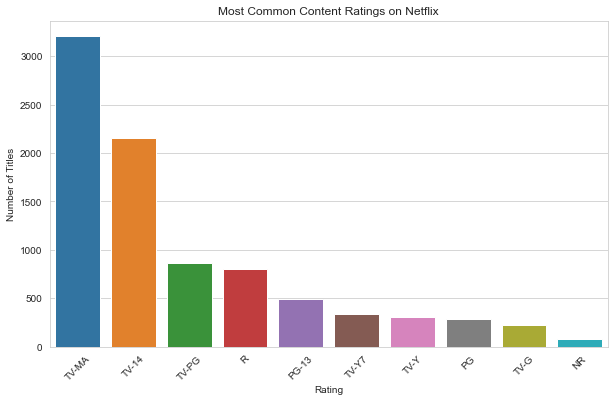

In [28]:
# Count rating categories
rating_counts = df["rating"].value_counts().head(10)

# Print results
print(rating_counts)

# Plot ratings
plt.figure(figsize=(10, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.title("Most Common Content Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

### Insight
The distribution of ratings helps show whether Netflix is primarily targeting family audiences, general audiences, or more mature viewers.  
This adds another layer to understanding Netflix's overall content positioning.

## Analysing release years

This section looks at when the content itself was originally released.  
This differs from `date_added`, which shows when it was added to Netflix.

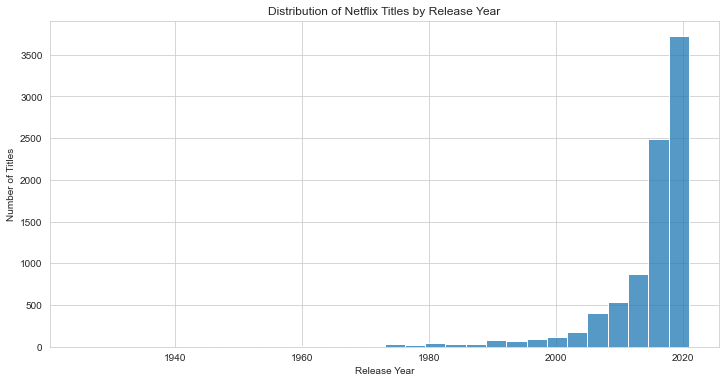

In [29]:
# Plot release year distribution
plt.figure(figsize=(12, 6))
sns.histplot(df["release_year"], bins=30)
plt.title("Distribution of Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

### Insight
This chart shows whether Netflix relies mainly on newer releases, older catalogue content, or a mix of both.  
A strong concentration in recent years would suggest a focus on newer content, while a wider spread would indicate catalogue depth.

## Comparing average release year by content type

To go beyond simple charts, I want to compare whether movies and TV shows on Netflix differ in how recently they were released.

In [30]:
# Calculate average release year by content type
avg_release_by_type = df.groupby("type")["release_year"].mean()

print(avg_release_by_type)

type
Movie      2013.121514
TV Show    2016.605755
Name: release_year, dtype: float64


### Insight
If TV shows have a more recent average release year than movies, that may suggest Netflix is investing more heavily in recent episodic content than in older film catalogues.

# Conclusion

This analysis explored how Netflix's content strategy has evolved over time using its catalogue of movies and TV shows.

## Key Findings
- Netflix significantly expanded the number of titles added in later years.
- Movies make up the majority of the catalogue, although TV shows appear to have grown strongly over time.
- Content production is concentrated in a small number of countries.
- A few major genres dominate the catalogue.
- The platform's ratings mix provides insight into its target audience.

## Final Interpretation
Overall, the results suggest that Netflix pursued a strategy of rapid catalogue expansion while maintaining a strong movie base and increasing its emphasis on series content. The country and genre patterns also suggest that Netflix balances global reach with concentration in a few key content markets.

## Portfolio Value
This project demonstrates core data analyst skills including:
- data cleaning
- exploratory data analysis
- trend analysis
- visualisation
- business interpretation